In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Players_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [ ]:
df.columns.tolist()
#memphis = df[df['player_name'] == 'Memphis Zerrouki']
#memphis[['match_date', 'opponent', 'goals', 'expected_goals_xg', 'position']]

['player_id',
 'player_name',
 'age',
 'nationality',
 'team',
 'jersey_number',
 'position',
 'height_cm',
 'weight_kg',
 'preferred_foot',
 'club_name',
 'market_value_eur',
 'match_id',
 'match_date',
 'stadium',
 'city',
 'opponent_team',
 'tournament_stage',
 'match_result',
 'goals_team',
 'goals_opponent',
 'minutes_played',
 'goals',
 'assists',
 'shots',
 'shots_on_target',
 'expected_goals_xg',
 'expected_assists_xa',
 'key_passes',
 'successful_passes',
 'total_passes',
 'pass_accuracy',
 'dribbles_attempted',
 'successful_dribbles',
 'crosses',
 'successful_crosses',
 'tackles',
 'interceptions',
 'clearances',
 'blocks',
 'aerial_duels_won',
 'aerial_duels_lost',
 'recoveries',
 'defensive_actions',
 'fouls_committed',
 'fouls_suffered',
 'yellow_cards',
 'red_cards',
 'offsides',
 'saves',
 'save_percentage',
 'punches',
 'clean_sheet',
 'goals_conceded',
 'penalty_saves',
 'distance_covered_km',
 'sprint_distance_km',
 'top_speed_kmh',
 'accelerations',
 'decelerations',

In [ ]:
memphis = df[df['player_name'] == 'Memphis Zerrouki']
memphis[['match_date', 'opponent_team', 'goals', 'shots', 'shots_on_target', 'expected_goals_xg', 'minutes_played', 'position']]

,match_date,opponent_team,goals,shots,shots_on_target,expected_goals_xg,minutes_played,position
84,16-07-2026,Peru,1,1,0,0.03,90,Forward
252,25-06-2026,Brazil,0,0,0,0.00,0,Forward
1006,18-06-2026,England,0,0,0,0.00,0,Forward
1809,16-06-2026,Qatar,0,0,0,0.00,0,Forward
3033,21-06-2026,Ukraine,0,0,0,0.00,0,Forward
4541,08-07-2026,Nigeria,0,0,0,0.00,0,Forward
6542,29-06-2026,Ghana,0,0,0,0.00,0,Forward
6565,24-07-2026,Ukraine,0,2,0,0.21,31,Forward
8120,08-07-2026,Ghana,0,0,0,0.10,73,Forward
9851,27-07-2026,Ukraine,0,0,0,0.00,0,Forward


In [ ]:
memphis.shape[0]  # how many matches did he play?
memphis['goals'].sum()  # sanity check - should be 24
memphis.sort_values('goals', ascending=False)[['match_date', 'opponent_team', 'goals', 'shots', 'expected_goals_xg']].head(10)

,match_date,opponent_team,goals,shots,expected_goals_xg
38411,11-06-2026,Belgium,4,4,0.04
53905,24-07-2026,Canada,3,3,0.00
19352,24-06-2026,Saudi Arabia,2,1,0.00
52911,29-06-2026,Canada,2,2,0.01
12093,19-07-2026,Costa Rica,2,2,0.02
17034,23-07-2026,Jamaica,1,3,0.00
23534,25-06-2026,Canada,1,6,0.27
38670,19-07-2026,Australia,1,4,0.07
44412,23-07-2026,Peru,1,2,0.00
45269,17-06-2026,Poland,1,3,0.78


In [ ]:
player_totals = df.groupby('player_name')[['goals', 'shots', 'expected_goals_xg']].sum().reset_index()
player_totals['overperformance'] = player_totals['goals'] - player_totals['expected_goals_xg']
player_totals.sort_values('overperformance', ascending=False).head(15)

,player_name,goals,shots,expected_goals_xg,overperformance
794,Memphis Zerrouki,24,82,3.22,20.78
652,Kasey Hector,16,77,2.90,13.10
833,Mohannad Majeed,15,53,2.13,12.87
374,Eric Rodriguez,15,71,2.15,12.85
99,Andre Bassogog,13,55,1.69,11.31
1147,Themba Xoki,13,81,1.72,11.28
963,Randal Duarte,14,49,2.77,11.23
371,Eric Mba,14,105,3.15,10.85
1050,Saman Azmoun,13,40,2.23,10.77
1161,Timothy Weah,12,46,1.27,10.73


In [ ]:
player_totals[['goals', 'expected_goals_xg']].mean()
player_totals['goals'].sum() / player_totals['expected_goals_xg'].sum()

np.float64(3.4374964476929897)

In [ ]:
player_age_perf = df.groupby('player_name').agg({
    'age': 'first',       # age doesn't change during the tournament, so just grab it once
    'player_rating': 'mean'   # average rating across their matches
}).reset_index()

player_age_perf.head()

,player_name,age,player_rating
0,Aaron Goodwin,23,3.412766
1,Aaron Metcalfe,26,3.872340
2,Aaron Souttar,28,2.021277
3,Aaron Wright,23,4.529787
4,Abdallah El-Shenawy,28,3.468889


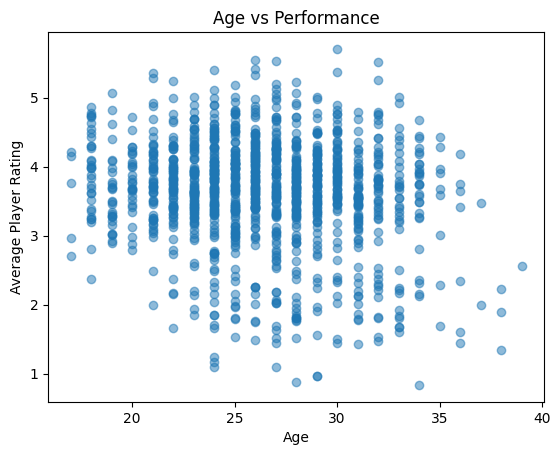

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(player_age_perf['age'], player_age_perf['player_rating'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Average Player Rating')
plt.title('Age vs Performance')
plt.show()

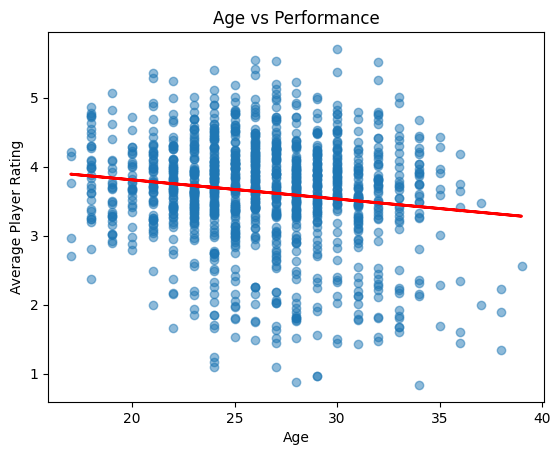

In [ ]:
import numpy as np

z = np.polyfit(player_age_perf['age'], player_age_perf['player_rating'], 1)
p = np.poly1d(z)
plt.scatter(player_age_perf['age'], player_age_perf['player_rating'], alpha=0.5)
plt.plot(player_age_perf['age'], p(player_age_perf['age']), color='red', linewidth=2)
plt.xlabel('Age')
plt.ylabel('Average Player Rating')
plt.title('Age vs Performance')
plt.show()

In [ ]:
player_age_perf['age'].corr(player_age_perf['player_rating'])

np.float64(-0.14509964930540978)